# LSTM의 기억 구조와 PyTorch 사용법

LSTM(Long Short-Term Memory)은 기본 RNN에 **셀 상태와 게이트**를 추가하여 오래 유지할 정보와 새로 기록할 정보를 구분하는 순환 신경망이다. 문장 앞부분의 단서가 뒤쪽 판단에 필요하거나 시계열의 이전 패턴을 오래 참고해야 할 때 사용한다.

이 노트북에서는 LSTM 자체의 동작을 먼저 이해한 뒤, 같은 입력을 기본 RNN에 넣었을 때와 반환값·파라미터가 어떻게 달라지는지 확인한다. 마지막에는 LSTM의 은닉 상태가 문장 분류 점수로 연결되는 과정과 다층·양방향 설정의 shape 변화를 살펴본다.

## 01. LSTM이 필요한 이유: 장기 의존성

**장기 의존성(Long-term Dependency)** 은 현재 위치의 판단에 시퀀스 앞부분의 정보가 필요한 관계이다. 예를 들어 다음 빈칸을 예측하려면 가까운 단어뿐 아니라 앞에서 제시한 국가 정보도 기억해야 한다.

```text
나는 프랑스에서 태어나 오랫동안 그곳에서 생활했다.
그래서 나는 프랑스어를 유창하게 ____.
```

기본 RNN은 토큰을 하나씩 읽으며 은닉 상태 하나를 계속 갱신한다. 시퀀스가 길어지면 새로운 정보가 반복해서 섞이고, 역전파 과정의 기울기가 매우 작아져 앞부분 단서를 충분히 학습하지 못할 수 있다. 기본 RNN이 긴 문장을 절대 처리하지 못한다는 뜻은 아니지만, 중요한 정보를 오래 보존하는 경로가 명확하지 않다는 한계가 있다.

LSTM은 **이전 기억에서 무엇을 남길지**, **현재 입력에서 무엇을 새로 기록할지**, **현재 출력으로 무엇을 내보낼지**를 각각 학습한다. 따라서 기본 RNN보다 장기 정보를 유지하기 쉬운 구조를 제공하지만, 모든 장기 의존성을 자동으로 해결하거나 항상 더 높은 성능을 보장하지는 않는다.

## 02. 셀 상태와 게이트

LSTM은 각 토큰 위치에서 **셀 상태 $C_t$** 와 **은닉 상태 $h_t$** 를 함께 만든다. 셀 상태는 중요한 정보를 다음 위치까지 오래 전달하는 장기 기억 경로이고, 은닉 상태는 현재 위치까지 읽은 내용을 요약한 출력이자 다음 게이트 계산에 사용하는 상태이다.

게이트는 사람이 미리 정한 규칙이 아니라 학습되는 가중치로 계산한 `0~1` 범위의 벡터이다. 벡터의 각 값이 해당 위치의 정보를 얼마나 통과시킬지 조절한다.

- **망각 게이트 $f_t$**: 이전 셀 상태에서 유지할 정보의 비율
- **입력 게이트 $i_t$**: 새 후보 정보에서 셀 상태에 기록할 비율
- **후보 정보 $g_t$**: 현재 입력으로부터 만든 새로운 기억 후보
- **출력 게이트 $o_t$**: 현재 셀 상태에서 은닉 상태로 내보낼 비율

세 게이트가 입력 → 망각 → 출력 순서로 차례로 실행되는 것은 아니다. 현재 입력 $x_t$와 이전 은닉 상태 $h_{t-1}$를 이용해 네 값을 함께 계산한 뒤, 셀 상태를 먼저 갱신하고 은닉 상태를 만든다.

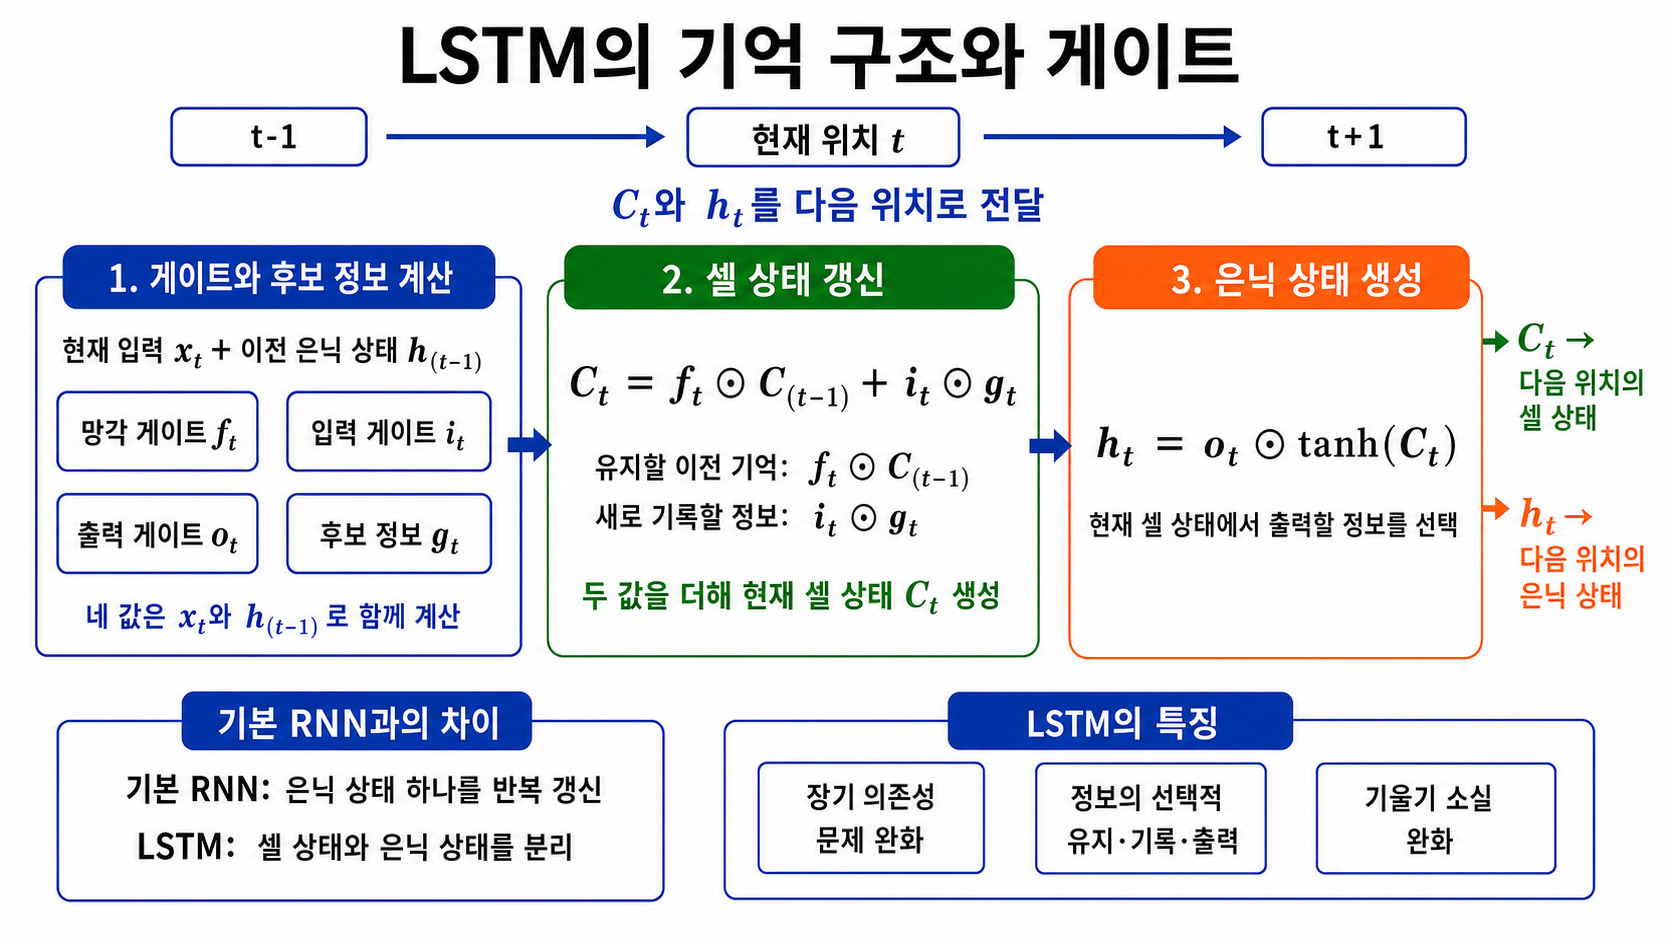

### 한 타임 스텝의 상태 갱신

망각 게이트가 선택한 이전 기억과 입력 게이트가 선택한 새 후보 정보를 더해 현재 셀 상태를 만든다. 출력 게이트는 갱신된 셀 상태 중 현재 은닉 상태로 내보낼 양을 정한다.

```text
C_t = f_t ⊙ C_{t-1} + i_t ⊙ g_t
h_t = o_t ⊙ tanh(C_t)
```

`⊙`는 같은 위치의 값끼리 곱하는 **하다마르 곱(Hadamard Product)** 이다. `sigmoid`는 게이트 값을 `0~1` 범위로 만들고, `tanh`는 후보 정보와 셀 상태를 `-1~1` 범위로 조정한다. `tanh`는 **하이퍼볼릭 탄젠트**라고 읽는다.

실제 상태는 벡터이지만 한 위치의 값만 숫자로 단순화하면 다음처럼 읽을 수 있다.

```text
이전 기억                  : C_(t-1) = 0.80
망각 게이트가 남긴 기억    : 0.90 × 0.80 = 0.72
입력 게이트가 기록한 새 정보: 0.25 × (-0.40) = -0.10
현재 셀 상태              : C_t = 0.72 + (-0.10) = 0.62
현재 은닉 상태            : h_t = 0.70 × tanh(0.62) ≈ 0.39
```

이 예시는 연산을 읽기 위한 값이며 `0.90`이 항상 중요한 정보, `0.25`가 항상 덜 중요한 정보를 뜻하는 것은 아니다. 실제 게이트 값은 데이터와 학습된 가중치에 따라 달라진다.

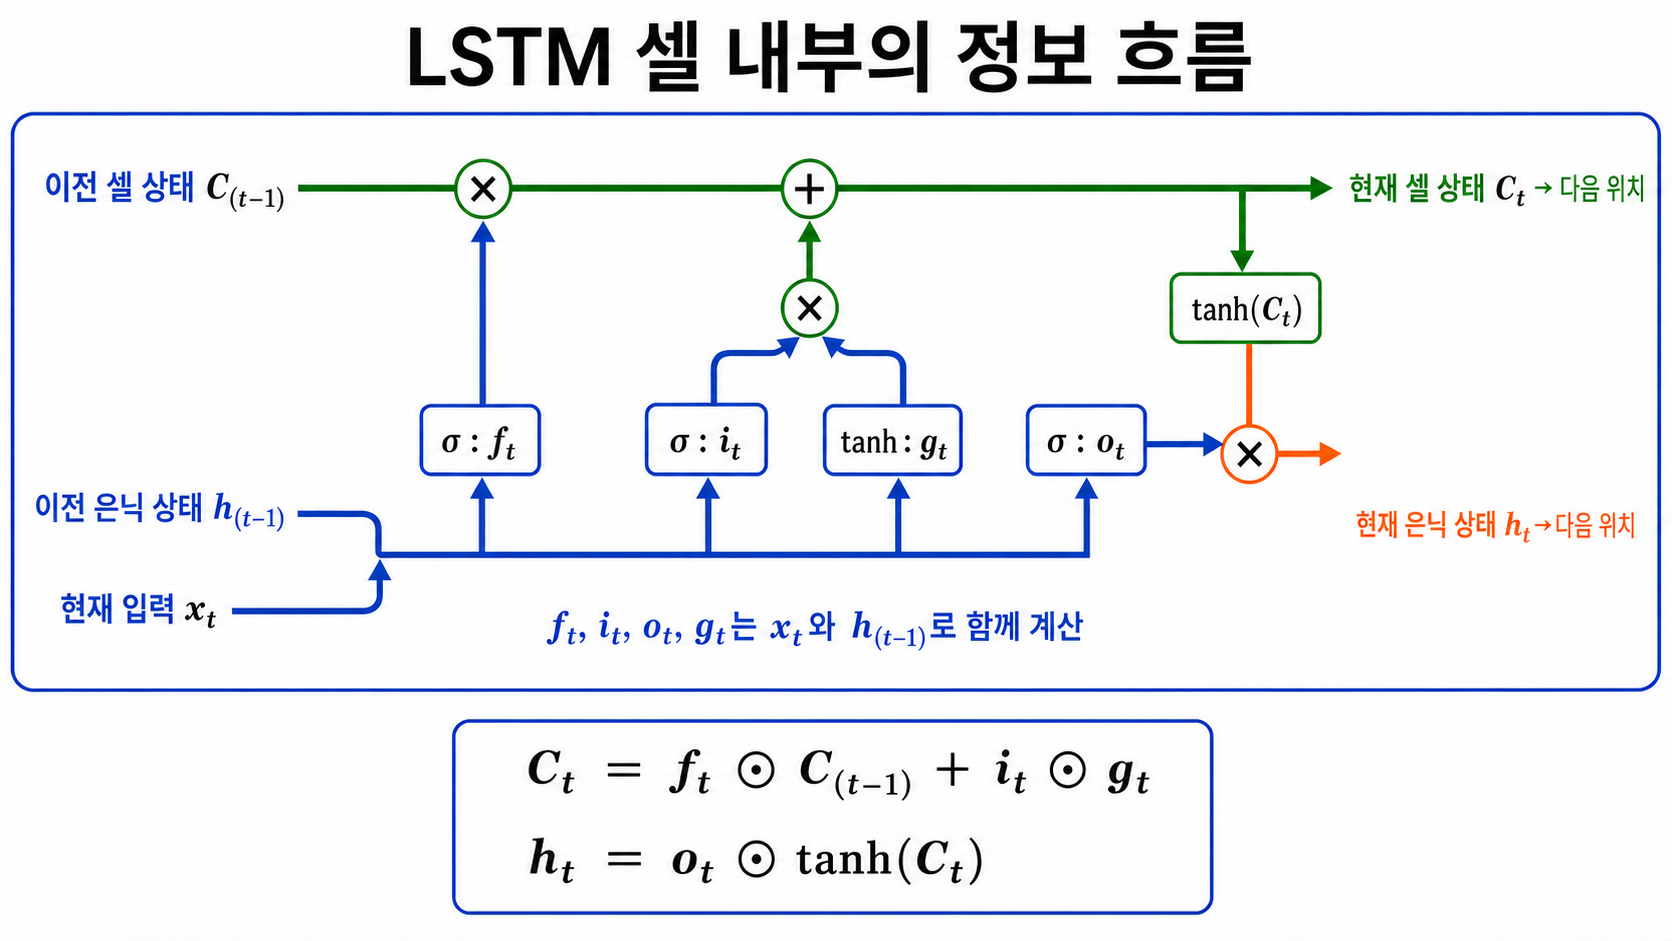

### 문장 속 토큰을 처리하는 방식

다음과 같이 네 토큰으로 이루어진 두 문장을 생각할 수 있다.

```text
문장 0: 영화 → 정말 → 재미 → 있다
문장 1: 영화 → 전혀 → 재미 → 없다
```

LSTM은 두 문장을 한 번에 입력받을 수 있지만 각 문장의 기억은 서로 섞이지 않는다. 문장마다 첫 토큰부터 마지막 토큰까지 순서대로 처리하면서 자신의 셀 상태와 은닉 상태를 갱신한다.

학습된 모델은 `전혀`에서 얻은 정보를 이후 `재미`, `없다`를 처리할 때 활용할 수 있다. 다만 게이트에 “부정 표현을 기억하라”는 규칙이 미리 들어 있는 것은 아니다. 감성 정답과 손실을 이용한 학습을 통해 어떤 정보를 유지해야 예측 오차가 줄어드는지 가중치가 조정된다.

## 03. PyTorch에서 LSTM의 입력과 반환값

`batch_first=True`인 `nn.LSTM`은 입력을 `(배치 크기, 시퀀스 길이, 입력 특성 수)` 순서로 받는다. 다음 코드의 입력 `(2, 4, 3)`은 문장 2개, 문장마다 토큰 위치 4개, 각 위치를 나타내는 숫자 3개를 뜻한다.

```text
입력 sentence_input : (B, L, F) = (2, 4, 3)
output              : (B, L, H) = (2, 4, 5)
hidden              : (층×방향, B, H) = (1, 2, 5)
cell                : (층×방향, B, H) = (1, 2, 5)
```

- **`output`**: 네 토큰 위치에서 만들어진 은닉 상태 $h_1, h_2, h_3, h_4$를 모두 보관한 텐서
- **`hidden`**: 마지막 토큰까지 처리한 뒤 남은 최종 은닉 상태
- **`cell`**: 마지막 토큰까지 처리한 뒤 남은 최종 셀 상태

`hidden`과 `cell`은 shape가 같아도 역할과 값이 다르다. 한 층 단방향 LSTM에서는 `output[:, -1, :]`와 `hidden[-1]`이 같은 마지막 은닉 상태를 가리키지만, `cell`은 별도의 장기 기억이다.

코드에서는 같은 입력을 기본 RNN에도 전달한다. 비교의 목적은 LSTM이 `cell`을 추가로 반환한다는 사실을 확인하는 것이다. 학습 전 무작위 벡터의 크기로는 모델 우열을 판단할 수 없다. `sentence_input`은 shape를 설명하기 위한 수치이며 학습된 단어 임베딩과는 다르다.

In [2]:
import torch
import torch.nn as nn

torch.manual_seed(42)

sentence_tokens = [
    ["영화", "정말", "재미", "있다"],
    ["영화", "전혀", "재미", "없다"],
]

batch_size = len(sentence_tokens) # 한번에 처리하는 문장 수 : 2
sequence_length = len(sentence_tokens[0]) # 문장마다 처리할 토큰 위치 : 4
input_size = 3 # 토큰 하나를 표현하는 벡터 차원 수
hidden_size = 5 # 각 토큰 처리 후 만드는 은닉 상태

# (2, 4, 3) 형태의 샘플 데이터 생성
# (B, L, F)
sentence_input = torch.arange(
    batch_size * sequence_length * input_size,
    dtype=torch.float32,
).reshape(batch_size, sequence_length, input_size) / 10

# RNN 모델과 LSTM 모델을 만들어서 비교
# -> torch 제공 RRN, LSTM 모델 생성 방법이 똑같다!
rnn = nn.RNN(
    input_size=input_size,
    hidden_size=hidden_size,
    batch_first=True,
)
lstm = nn.LSTM(
    input_size=input_size,
    hidden_size=hidden_size,
    batch_first=True,
)

# RNN은 순전파 진행 시 모든 은닉 상태 output과
# 마지막 은닉 상태 hidden을 반환
rnn_output, rnn_hidden = rnn(sentence_input)

# LSTM은 순전파 진행 시
# RNN과 똑같이 output, hidden 반환하면서
# 추가로 cell(장기 기억 통로)을 반환
lstm_output, (lstm_hidden, lstm_cell) = lstm(sentence_input)

print("공통 입력 shape:", sentence_input.shape)
print("RNN output / hidden:", rnn_output.shape, rnn_hidden.shape)
# output(2, 4, 5) : 2 문장 - 4 토큰 입력 시 은닉 상태로 벡터 값이 5개 출력됨
# hidden(1, 2, 5) : 1번 입력 시 2 문장 입력 - 마지막에 각 문장별 5개 벡터값이 출력ㄱ

print(
    "LSTM output / hidden / cell:",
    lstm_output.shape, # (2, 4, 5)
    lstm_hidden.shape, # (1, 2, 5)
    lstm_cell.shape, # (1, 2, 5)
    # 1 : 단층 또는 단방향 LSTM
    # 2 : 입력 문장의 수
    # 5 : 문장마다 남긴 장기 기억 벡터 차원 수
)

print(
    "RNN 첫 문장 최종 hidden:",
    rnn_hidden[-1, 0].detach().round(decimals=4),
)
print(
    "LSTM 첫 문장 최종 hidden:",
    lstm_hidden[-1, 0].detach().round(decimals=4),
)
print(
    "LSTM 첫 문장 최종 cell:",
    lstm_cell[-1, 0].detach().round(decimals=4),
)

공통 입력 shape: torch.Size([2, 4, 3])
RNN output / hidden: torch.Size([2, 4, 5]) torch.Size([1, 2, 5])
LSTM output / hidden / cell: torch.Size([2, 4, 5]) torch.Size([1, 2, 5]) torch.Size([1, 2, 5])
RNN 첫 문장 최종 hidden: tensor([0.4831, 0.3590, 0.3516, 0.7194, 0.6510])
LSTM 첫 문장 최종 hidden: tensor([-0.1015,  0.0257, -0.2313, -0.0307, -0.1101])
LSTM 첫 문장 최종 cell: tensor([-0.2043,  0.0879, -0.5042, -0.1345, -0.4400])


## 04. 한 타임 스텝의 게이트 계산

PyTorch의 `nn.LSTM`은 입력·망각·후보·출력 계산에 사용하는 가중치를 하나의 큰 텐서에 이어 붙여 저장한다. `weight_ih_l0`은 현재 입력 $x_t$에 적용하는 가중치이고, `weight_hh_l0`은 이전 은닉 상태 $h_{t-1}$에 적용하는 가중치이다.

PyTorch의 저장 순서는 입력 게이트 `i`, 망각 게이트 `f`, 후보 정보 `g`, 출력 게이트 `o`이다. `hidden_size=5`이면 각 계산에 행 5개가 필요하므로 합쳐진 첫 번째 축은 `4 × 5 = 20`이 된다.

다음 코드는 첫 번째 토큰 위치만 선택해 네 계산으로 나누고 $C_1$과 $h_1$을 직접 만든다. 직접 계산한 `manual_hidden`이 `lstm_output[:, 0, :]`과 같으면 앞에서 본 수식이 실제 `nn.LSTM`의 첫 위치 연산과 일치한 것이다.

In [3]:
first_input = sentence_input[:, 0, :]

# 단층 단방향 LSTM의 초기 hidden과 cell모두 0으로 초기화
previous_hidden = torch.zeros(batch_size, hidden_size)
previous_cell = torch.zeros(batch_size, hidden_size)

gate_linear = (
    first_input @ lstm.weight_ih_l0.T
    + lstm.bias_ih_l0
    + previous_hidden @ lstm.weight_hh_l0.T
    + lstm.bias_hh_l0
)

input_linear, forget_linear, candidate_linear, output_linear = gate_linear.chunk(
    4,
    dim=1,
)

input_gate = torch.sigmoid(input_linear)
forget_gate = torch.sigmoid(forget_linear)
candidate = torch.tanh(candidate_linear)
output_gate = torch.sigmoid(output_linear)

# 현재 cell = 이전 cell에 유지할 부분 + 새 후보에서 기록할 부분
manual_cell = forget_gate * previous_cell + input_gate * candidate

# 현재 cell을 tanh 조정하고 출력 게이트 비율을 곱해서 현재 hidden state 생성
manual_hidden = output_gate * torch.tanh(manual_cell)

print("합쳐진 게이트 선형결과 shape:", gate_linear.shape)
print(
    "i / f / g / o shape:",
    input_gate.shape,
    forget_gate.shape,
    candidate.shape,
    output_gate.shape,
)
print(
    "첫 문장 input gate:",
    input_gate[0].detach().round(decimals=4),
)
print(
    "첫 문장 forget gate:",
    forget_gate[0].detach().round(decimals=4),
)
print(
    "첫 문장 output gate:",
    output_gate[0].detach().round(decimals=4),
)

print(
    "직접 계산한 h1과 LSTM output의 첫 위치가 같은가:",
    torch.allclose(
        manual_hidden,
        lstm_output[:, 0, :],
        atol=1e-6,
    ),
)

합쳐진 게이트 선형결과 shape: torch.Size([2, 20])
i / f / g / o shape: torch.Size([2, 5]) torch.Size([2, 5]) torch.Size([2, 5]) torch.Size([2, 5])
첫 문장 input gate: tensor([0.4591, 0.6433, 0.4722, 0.5123, 0.5438])
첫 문장 forget gate: tensor([0.6295, 0.5285, 0.3807, 0.4272, 0.3779])
첫 문장 output gate: tensor([0.4988, 0.4880, 0.5598, 0.3656, 0.4350])
직접 계산한 h1과 LSTM output의 첫 위치가 같은가: True


## 05. 기본 RNN과 파라미터 수 비교

RNN과 LSTM은 PyTorch 호출 방식이 비슷하지만 내부 계산량이 다르다. 기본 RNN은 새 은닉 상태를 만들기 위한 가중치 묶음 하나를 학습하고, LSTM은 입력·망각·후보·출력에 해당하는 네 묶음을 학습한다.

같은 `input_size=3`, `hidden_size=5`인 한 층 단방향 계층에서 RNN의 입력 가중치는 `(5, 3)`, LSTM의 입력 가중치는 `(20, 3)`이다. 순환 가중치도 각각 `(5, 5)`와 `(20, 5)`가 된다.

파라미터가 많으면 정보를 조절할 수 있는 계산이 늘어나지만 학습 시간, 메모리 사용량과 과적합 가능성도 커질 수 있다. 따라서 LSTM을 사용했다는 이유만으로 성능이 좋아진다고 단정하지 않고 같은 데이터와 평가 기준으로 검증해야 한다.

In [ ]:
rnn_parameter_count = sum(
    parameter.numel()
    for parameter in rnn.parameters()
)
lstm_parameter_count = sum(
    parameter.numel()
    for parameter in lstm.parameters()
)

print("RNN 입력 가중치 shape:", rnn.weight_ih_l0.shape)
print("LSTM 입력 가중치 shape:", lstm.weight_ih_l0.shape)
print("RNN 순환 가중치 shape:", rnn.weight_hh_l0.shape)
print("LSTM 순환 가중치 shape:", lstm.weight_hh_l0.shape)
print("RNN 파라미터 수:", rnn_parameter_count)
print("LSTM 파라미터 수:", lstm_parameter_count)
print(
    "LSTM / RNN 파라미터 수 비율:",
    lstm_parameter_count / rnn_parameter_count,
)

## 06. 마지막 은닉 상태를 문장 분류에 사용하기

문장 전체에 긍정·부정 레이블 하나를 예측할 때는 마지막 은닉 상태를 문장 벡터로 사용할 수 있다. 현재 한 층 단방향 모델에서는 `lstm_hidden[-1]`의 shape가 `(문장 수, hidden_size)=(2, 5)`이고, 각 행은 한 문장을 5개의 값으로 요약한 벡터이다.

`nn.Linear(5, 1)`은 문장 벡터 5개 값을 가중합하여 문장마다 로짓 하나를 만든다. 로짓은 시그모이드를 적용하기 전의 원시 분류 점수이다.

```text
토큰 위치별 입력 (2, 4, 3)
        ↓ LSTM
마지막 은닉 상태 (2, 5)
        ↓ Linear
문장별 로짓 (2,)
```

다음 코드에서는 RNN과 LSTM의 마지막 은닉 상태를 같은 `Linear` 계층에 넣어 내부 표현이 달라지면 로짓도 달라진다는 점을 확인한다. 아직 모델을 학습하지 않았으므로 출력된 시그모이드 값을 실제 긍정·부정 확률이나 성능 차이로 해석하면 안 된다. 실제 감성 분류는 뒤의 NSMC 교안에서 손실함수와 optimizer를 사용해 학습한다.

In [10]:
torch.manual_seed(7)
shared_readout = nn.Linear(hidden_size, 1) # (5, 1)

# rnn, lstm 마지막 hidden 층(2 문장) 선택
rnn_sentence_vectors = rnn_hidden[-1] # (2, 5)
lstm_sentence_vectors = lstm_hidden[-1] # (2, 5)

# logits 구하기
rnn_logits = shared_readout(rnn_sentence_vectors).squeeze(1)
lstm_logits = shared_readout(lstm_sentence_vectors).squeeze(1)

# print(rnn_logits)

# sigmoid로 활성화 (0~1)
# - rnn, lstm 모델이 학습이 된 상태가 아니기 때문에 실제 확률은 아님
rnn_probabilities = torch.sigmoid(rnn_logits)
lstm_probabilities = torch.sigmoid(lstm_logits)

print(
    "RNN 학습 전 로짓:",
    rnn_logits.detach().round(decimals=4),
)
print(
    "LSTM 학습 전 로짓:",
    lstm_logits.detach().round(decimals=4),
)
print(
    "RNN 학습 전 sigmoid 값:",
    rnn_probabilities.detach().round(decimals=4),
)
print(
    "LSTM 학습 전 sigmoid 값:",
    lstm_probabilities.detach().round(decimals=4),
)

RNN 학습 전 로짓: tensor([-0.1532, -0.2230])
LSTM 학습 전 로짓: tensor([-0.0881, -0.1082])
RNN 학습 전 sigmoid 값: tensor([0.4618, 0.4445])
LSTM 학습 전 sigmoid 값: tensor([0.4780, 0.4730])


## 07. 다층 LSTM과 양방향 LSTM

`num_layers=2`는 첫 번째 LSTM 층의 위치별 출력을 두 번째 LSTM 층에 전달한다. 최종 `output`에는 마지막 층의 위치별 출력만 들어가지만, `hidden`과 `cell`의 첫 번째 축에는 각 층의 최종 상태가 저장된다.

`bidirectional=True`는 같은 시퀀스를 앞→뒤와 뒤→앞 두 방향으로 읽는다. 두 방향의 위치별 출력을 특성 축으로 연결하므로 `output`의 마지막 축은 `hidden_size × 2`가 된다. `hidden`과 `cell`의 첫 번째 축도 `층 수 × 방향 수`로 계산한다.

양방향 LSTM은 영화 리뷰처럼 문장 전체가 이미 주어진 분류 작업에 사용할 수 있다. 반면 미래 토큰을 볼 수 없는 실시간 예측이나 다음 토큰 생성에는 뒤→앞 방향을 그대로 사용할 수 없다.

In [8]:

# LSTM을 여러 층으로 쌓아주면 추상적인 문맥의 특징 학습이 더 잘 된다.
stacked_lstm = nn.LSTM(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=2,
    batch_first=True,
)
stacked_output, (stacked_hidden, stacked_cell) = stacked_lstm(
    sentence_input
)

# 양방향 lstm
bidirectional_lstm = nn.LSTM(
    input_size=input_size,
    hidden_size=hidden_size,
    batch_first=True,
    bidirectional=True,
)
bidirectional_output, (
    bidirectional_hidden,
    bidirectional_cell,
) = bidirectional_lstm(sentence_input)

print(
    "2층 LSTM output / hidden / cell:",
    stacked_output.shape,
    stacked_hidden.shape,
    stacked_cell.shape,
)
print(
    "양방향 LSTM output / hidden / cell:",
    bidirectional_output.shape,
    bidirectional_hidden.shape,
    bidirectional_cell.shape,
)

2층 LSTM output / hidden / cell: torch.Size([2, 4, 5]) torch.Size([2, 2, 5]) torch.Size([2, 2, 5])
양방향 LSTM output / hidden / cell: torch.Size([2, 4, 10]) torch.Size([2, 2, 5]) torch.Size([2, 2, 5])


## 08. LSTM 핵심 정리

LSTM은 기본 RNN의 은닉 상태에 셀 상태와 게이트를 추가해 기억을 선택적으로 유지·기록·출력하는 모델이다.

- **셀 상태 $C_t$**: 중요한 정보를 여러 토큰 위치에 걸쳐 전달하는 장기 기억 경로
- **은닉 상태 $h_t$**: 현재 위치까지 읽은 내용을 요약한 출력이자 다음 계산에 사용하는 상태
- **망각·입력 게이트**: 이전 기억에서 유지할 정보와 현재 입력에서 새로 기록할 정보를 조절
- **출력 게이트**: 갱신된 셀 상태에서 현재 은닉 상태로 내보낼 정보를 조절
- **PyTorch 반환값**: `output, (hidden, cell)`
- **문장 분류 사용처**: 마지막 은닉 상태를 `Linear`에 전달해 문장별 로짓 생성

기본 RNN보다 장기 정보를 보존하기 쉬운 구조이지만 계산량과 파라미터가 증가한다. 다음 GRU는 별도의 셀 상태를 제거하고 두 게이트로 기억을 조절하므로, LSTM과 구조·반환값·학습 성능을 함께 비교해 선택해야 한다.